In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

import matplotlib.pyplot as plt
import seaborn as sns

# **Load Dataset**

In [ ]:
df = pd.read_csv("predictive_maintenance.csv")

df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Failure Type
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,No Failure
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,No Failure
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,No Failure
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,No Failure
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,No Failure


# **EDA**

In [ ]:
df.isnull().sum()
df.dropna(inplace=True)
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Type                     10000 non-null  int64  
 1   Air temperature [K]      10000 non-null  float64
 2   Process temperature [K]  10000 non-null  float64
 3   Rotational speed [rpm]   10000 non-null  int64  
 4   Torque [Nm]              10000 non-null  float64
 5   Tool wear [min]          10000 non-null  int64  
 6   Target                   10000 non-null  int64  
dtypes: float64(3), int64(4)
memory usage: 547.0 KB


,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,0.500300,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900
std,0.671301,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981
min,0.000000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000
25%,0.000000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000
50%,0.000000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000
75%,1.000000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000
max,2.000000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000


# **Encode Machine Type**

In [ ]:
df["Type"] = df["Type"].map({"L":0,"M":1,"H":2})

# **Data Cleaning**

In [ ]:
df = df.drop(["UDI","Product ID","Failure Type"], axis=1)

# **Define Features and Target**

In [ ]:
X = df.drop("Target", axis=1)
y = df["Target"]

# **Train-Test Split**

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.2, random_state=42
)

# **Data Scaling**

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
df.head()

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target
0,1,298.1,308.6,1551,42.8,0,0
1,0,298.2,308.7,1408,46.3,3,0
2,0,298.1,308.5,1498,49.4,5,0
3,0,298.2,308.6,1433,39.5,7,0
4,0,298.2,308.7,1408,40.0,9,0


# **Train Machine Learning Models**

## **Regression model**

In [ ]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression()

log_model.fit(X_train, y_train)

log_pred = log_model.predict(X_test)

## **KNN model**

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors=5)

knn_model.fit(X_train, y_train)

knn_pred = knn_model.predict(X_test)

# **Evalution matrics R2**

In [ ]:
from sklearn.metrics import accuracy_score

log_acc = accuracy_score(y_test, log_pred)
knn_acc = accuracy_score(y_test, knn_pred)

print("Logistic Regression Accuracy:", log_acc)
print("KNN Accuracy:", knn_acc)

Logistic Regression Accuracy: 0.973
KNN Accuracy: 0.979


In [ ]:
sample_machine = [[1,300,310,1500,40,20]]

sample_scaled = scaler.transform(sample_machine)

prob = log_model.predict_proba(sample_scaled)

print("Failure Probability:", prob[0][1]*100,"%")

Failure Probability: 0.14371074023179176 %


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


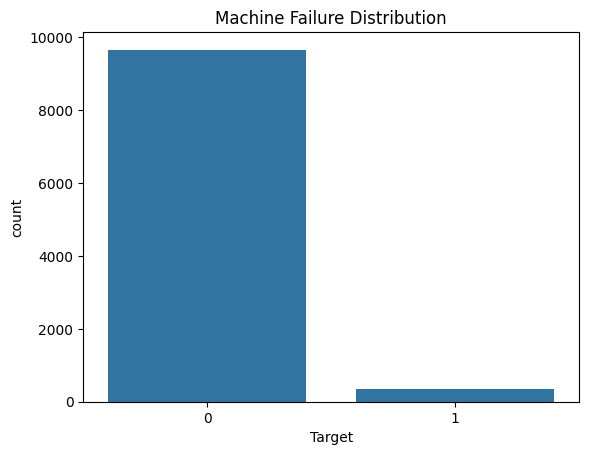

In [51]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="Target", data=df)
plt.title("Machine Failure Distribution")
plt.show()

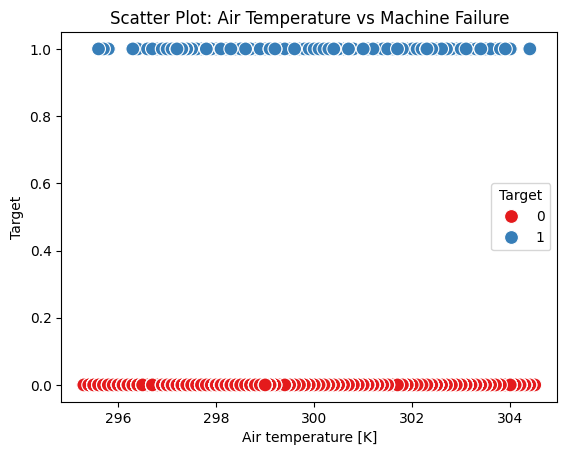

In [52]:
import seaborn as sns
import matplotlib.pyplot as plt

# Scatter plot of Air temperature vs Target
sns.scatterplot(x="Air temperature [K]", y="Target", data=df, hue="Target", palette="Set1", s=100)
plt.title("Scatter Plot: Air Temperature vs Machine Failure")
plt.show()

In [ ]:
import pickle

pickle.dump(log_model, open("model.pkl","wb"))
pickle.dump(scaler, open("scaler.pkl","wb"))